# 参数估计和假设检验

参数估计是利用样本对总体进行统计推断的一类方法， 即假定总体的概率分布类型已知，但其中含有未知参数，由样本估计未知参数的值．参数估计的方法主要有点估计和区间估计，其中点估计中有矩估计和极大似然估计等方法．

### 1.参数估计

##### （1）极大似然估计

In [2]:
import numpy as np
from scipy.stats import norm
a = np.loadtxt("Pdata4_6_2.txt")
h = a[:, ::2]
h = h.flatten()
miu = np.mean(h)
sigma = np.std(h)
print(f"样品均值和标准差为：{[miu, sigma]}")
print(f"极大似然估计值为：{norm.fit(h)}")

样品均值和标准差为：[170.25, 5.374709294464213]
极大似然估计值为：(170.25, 5.374709294464213)


##### （2） 区间估计

在$\texttt{scipy.stats}$模块中，还使用一个统计量，称为样本均值的标准误差 (SEM)，其定义为
$$
\text{SEM} = \frac{s}{n} \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}} \cdot \frac{1}{\sqrt{n}}.
$$
对应的 Python 函数为$\texttt{stats.sem(x)}$，其中$\texttt{x}$为样本的观测值向量。

有一大批糖果，现从中随机地取 16 袋，称得重量 (以 g 计) 如下

506 508 499 503 504 510 497 512

514 505 493 496 506 502 509 496

设袋装糖果的重量近似地服从正态分布. 试求总体均值$\mu$的置信水平为 0.95 的置信区间.

解 ：

$\mu$的一个置信水平为$1 - \alpha$的置信区间为$\left( \bar{X} \pm \frac{S}{\sqrt{n}} t_{\alpha/2}(n - 1) \right)$，这里显著性水平$\alpha = 0.05$, $\alpha/2 = 0.025$, $n - 1 = 15$, $t_{0.025}(15) = 2.1315$，由给出的数据算得$\bar{x} = 503.75$, $s = 6.2022$. 计算得总体均值$\mu$的置信水平为 0.95 的置信区间为
$$
(500.4451,\quad 507.0549)
$$

In [3]:
from scipy.stats import t
import numpy as np
a = np.array([506, 508, 499, 503, 504, 510, 497, 512, 514, 505, 493, 496, 506, 502, 509, 496])
miu = a.mean()
# ddof取值为1时，标准偏差除的是（N-1）；NumPy中的std计算默认是除以N
# 总体标准差除以N，样本标准差除以N-1
sigma = a.std(ddof=1)
print(miu, sigma)
alpha = 0.05
n = len(a)
# 注意.ppf中是 1-alpha
val = (miu-sigma/np.sqrt(n)*t.ppf(1-alpha/2, n-1), miu+sigma/np.sqrt(n)*t.ppf(1-alpha/2, n-1))
print(f"置信区间为：{val}")

503.75 6.202150164795002
置信区间为：(500.44510746243924, 507.05489253756076)


scipy.stats.t.interval(置信度, 自由度(n-1), loc=均值, scale=样本的标准方差)

In [5]:
import numpy as np
import scipy.stats as ss
a = np.array([506, 508, 499, 503, 504, 510, 497, 512, 514, 505, 493, 496, 506, 502, 509, 496])
alpha = 0.95
df = len(a) - 1
ci = ss.t.interval(alpha, df, loc=a.mean(), scale=ss.sem(a))
print(f"置信区间为：{ci}")

置信区间为：(500.44510746243924, 507.05489253756076)


### 2. 参数假设性检验

假设检验是统计推断的另一类重要问题，分为参数假设检验和非参数假设检验.参数假设检验是总体的分布函数形式已知，但其中含有未知参数为了推断总体的某些性质， 提出某些关于总体参数的假设， 然后根据样本对所提出的假设作出判断， 是接受还是拒绝这类统计推断问题就是所谓的参数假设检验问题．在总体的分布函数完全未知的情况下， 进行的假设检验称为非参数假设检验.

##### (1) 单个总体均值的假设性检验

1) 正态总体标准差$\sigma$已知的$Z$检验法

设总体$X \sim N(\mu, \sigma^2)$，其中$\mu$未知，$\sigma$已知，$X_1, X_2, \cdots, X_n$是来自$X$的样本.

提出原假设$H_0: \mu = \mu_0$，备择假设$H_1: \mu \neq \mu_1$.

检验统计量为
$$
Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}},
$$
检验的显著性水平为$\alpha$，标准正态分布的上$\alpha/2$分位数记作$z_{\alpha/2}$，当$Z$的观测值$z$满足$|z| > z_{\alpha/2}$时，拒绝原假设$H_0$，接受$H_1$；否则，接受$H_0$.


tstat全称：test statistic   pvalue:p value(p值)

tstat, pvalue = statsmodels.stats.weightstats.ztest(x1, x2=None, value=0, alternative='two-sided', usevar='pooled', ddof=1.0)

| 参数名             | 类型                                 | 说明                                                                                             |
| --------------- | ---------------------------------- | ---------------------------------------------------------------------------------------------- |
| **x1**          | 1-D array-like                     | 第一组样本数据。                                                                                       |
| **x2**          | 1-D array-like 或 None              | 第二组样本数据。若为 **None** → 做单样本 Z 检验；若给出 → 做两独立样本 Z 检验。                                             |
| **value**       | float                              | 待检验的 **总体均值（单样本）** 或 **两总体均值差（两样本）** 的零假设值。默认 0。                                               |
| **alternative** | {'two-sided', 'larger', 'smaller'} | 备择假设方向：<br>- 'two-sided'：≠ value（双侧检验，默认）<br>- 'larger'：> value（右尾）<br>- 'smaller'：< value（左尾） |
| **usevar**      | {'pooled', 'unequal'}              | 仅两样本时有效，指定方差估计方式：<br>- 'pooled'：用合并方差（等方差假设，默认）<br>- 'unequal'：用各自样本方差（Welch-Z）                |
| **ddof**        | int                                | 计算样本方差时的自由度修正（delta degrees of freedom）。默认 1（即除以 n-1）。                                         |

| 返回值        | 含义                                                                          |
| ---------- | --------------------------------------------------------------------------- |
| **tstat**  | **Z 统计量**（float）。单样本时为 $\frac{\bar x - \mu_0}{s/\sqrt{n}}$；两样本时为两组均值差的标准化值。 |
| **pvalue** | 与 **alternative** 对应的双侧或单侧 **p 值**。                                         |

# 重点
$\texttt{statsmodels}$库中的$\texttt{ztest}$函数使用的检验统计量为
$$
T = \frac{\bar{X} - \mu_0}{s / \sqrt{n}}.
$$
其中，$s$为样本方差，实际上它是我们下面介绍的单个总体$t$检验的统计量. 可以借助$T$统计量计算$Z$统计量的观测值，它们之间的关系为$z = t \frac{s}{\sigma}$.

ztest中公式使用样本标准差，所求为T统计量，要转化为Z统计量，只用乘一个$\frac{s}{\sigma}$，就可以转换为
$$
T = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}}.
$$

例 4.15 某车间用一台包装机包装糖果. 包得的袋装糖重是一个随机变量，它服从正态分布. 当机器正常时，其均值为 0.5kg，标准差为 0.015kg. 某日开工后为检验包装机是否正常，随机地抽取它所包装的糖 9 袋，称得净重 (kg) 为

0.497 0.506 0.518 0.524 0.498 0.511 0.520 0.515 0.512

问机器是否正常？

解 按题意总体$X \sim N(\mu, \sigma^2)$，$\mu$未知，$\sigma = 0.015$已知，要求在显著性水平$\alpha = 0.05$下检验假设
$$
H_0: \mu = 0.5,\quad H_1: \mu \neq 0.5.
$$

因$\sigma$已知，故采用$Z$检验，取检验统计量为$Z = \frac{\bar{X} - 0.5}{\sigma / \sqrt{n}}$，令$n = 9$, $\bar{x} = 0.5112$, $\alpha = 0.05$, $z_{\alpha/2} = 1.96$，拒绝域为
$$
|z| = \left| \frac{\bar{x} - 0.5}{\sigma / \sqrt{n}} \right| = 2.2444 > 1.96.
$$

因$Z$的观测值$z$落在拒绝域内，故在显著性水平$\alpha = 0.05$下拒绝原假设$H_0$，认为这天包装机工作不正常.

In [11]:
import numpy as np
from statsmodels.stats.weightstats import ztest
sigma = 0.015
a = np.array([0.497, 0.506, 0.518, 0.524, 0.498, 0.511, 0.520, 0.515, 0.512])
tstat1, pvalue = ztest(a, value=0.5)  # 计算T统计量的观测值及p值
tstat2 = tstat1*a.std(ddof=1) / sigma  # 转换为Z统计量的观测值
print(f"t值为：{round(tstat1, 4)}")
print(f"z值为：{round(tstat2, 4)}")
print(f"p值为：{round(pvalue, 4)}")

t值为：3.5849
z值为：2.2444
p值为：0.0003


In [12]:
# 直接求Z统计量，与上面交叉验证
import numpy as np
from scipy.stats import norm

a = np.array([0.497, 0.506, 0.518, 0.524, 0.498,
              0.511, 0.520, 0.515, 0.512])

mu0 = 0.5
sigma = 0.015
n = len(a)

# 样本均值
x_bar = a.mean()

# Z 统计量（σ 已知）
z = (x_bar - mu0) / (sigma / np.sqrt(n))

# 双侧 p 值
p = 2 * (1 - norm.cdf(abs(z)))

print(f"Z = {z:.4f}, p = {p:.4f}")

Z = 2.2444, p = 0.0248


##### (2) 正态总体标准差 $\sigma$ 未知的 $t$ 检验法

设总体$X \sim N(\mu, \sigma^2)$，其中$\mu, \sigma^2$未知，$X_1, X_2, \cdots, X_n$是来自总体$X$的样本.

提出原假设$H_0: \mu = \mu_0$，备择假设$H_1: \mu \neq \mu_0$.

检验统计量为
$$
T = \frac{\bar{X} - \mu_0}{S / \sqrt{n}},
$$
检验的显著性水平为$\alpha$，自由度为$n - 1$的$t$分布的上$\alpha/2$分位数为$t_{\alpha/2}(n - 1)$，拒绝域为$T$的观测值$t$满足
$$
|t| = \left| \frac{\bar{x} - \mu_0}{s / \sqrt{n}} \right| \geq t_{\alpha/2}(n - 1).
$$


某批矿砂的 5 个样品中的镍含量 (\%), 经测定为

3.25 3.27 3.24 3.26 3.24

设测定值总体服从正态分布，但参数均未知，问在$\alpha = 0.01$下能否接受假设：这批矿砂的镍含量的均值为 3.25.

解 ：

按题意总体$X \sim N(\mu, \sigma^2)$，$\mu, \sigma^2$均未知，要求在显著性水平$\alpha = 0.01$下检验假设
$$
H_0: \mu = 3.25,\quad H_1: \mu \neq 3.25.
$$

因$\sigma^2$未知，故采用$t$检验，取检验统计量为$t = \frac{\bar{X} - 3.25}{S / \sqrt{n}}$，令$n = 5$, $\bar{x} = 3.252$, $s = 0.0130$, $\alpha = 0.01$, $t_{\alpha/2}(n - 1) = t_{0.005}(4) = 4.6041$，拒绝域为
$$
|t| = \left| \frac{\bar{x} - 3.25}{s / \sqrt{n}} \right| \geq t_{\alpha/2}(n - 1) = 4.6041.
$$

因$|t|$的观测值$|t| = \left| \frac{3.252 - 3.25}{0.013 / \sqrt{5}} \right| = 0.3430 < 4.6041$，不落在拒绝域之内，故在显著性水平$\alpha = 0.01$下接受原假设$H_0$，即认为这批矿砂镍含量的均值为 3.25.

In [10]:
import numpy as np
from statsmodels.stats.weightstats import ztest
a = np.array([3.25, 3.27, 3.24, 3.26, 3.24])
tstat, pvalue = ztest(a, value=3.25)
print(f"检验统计量为：{tstat}")
print(f"p值为：{pvalue}")

检验统计量为：0.34299717028498317
p值为：0.7316005889599273


In [13]:
import numpy as np
from statsmodels.stats.weightstats import ztest
a = np.array([16, 25, 21, 20, 23, 21, 19, 15, 13, 23, 17, 20, 29, 18, 22, 16, 22])
tstat, pvalue = ztest(a, value=21)
print(f"检验统计量为：{tstat}")
print(f"p值为：{pvalue}")

检验统计量为：-1.0348266239966402
p值为：0.30074988685035464


### 2. 两个总体的假设检验

statsmodels.stats.weightstats.ttest_ind(x1, x2)

| 函数               | 主要参数          | 类型 / 默认值                                | 说明             | 返回值                                      | 类型                           |
| ---------------- | ------------- | --------------------------------------- | -------------- | ---------------------------------------- | ---------------------------- |
| `ttest_ind`      | `x1, x2`      | array-like                              | 两组独立样本         | t-statistic, p-value, degrees-of-freedom | `tuple[float, float, float]` |
|                  | `alternative` | `{'two-sided','smaller','larger'}`      | 备择假设方向         |                                          |                              |
|                  | `usevar`      | `{'pooled','unequal'}`                  | 方差齐性假设         |                                          |                              |
|                  | `weights`     | tuple(array-like, array-like), optional | 样本权重           |                                          |                              |



表 4.7 分别给出两位文学家马克·吐温 (Mark Twain) 的 8 篇小品文以及斯诺特格拉斯 (Snodgrass) 的 10 篇小品文中由 3 个字母组成的单词的比例.

\begin{center}
\begin{tabular}{c|cccccccccc}
\hline
\multicolumn{11}{c}{表 4.7 两位作家作品中单词统计数据} \\
\hline
马克·吐温 & 0.225 & 0.262 & 0.217 & 0.240 & 0.230 & 0.229 & 0.235 & 0.217 &  &  \\
斯诺特格拉斯 & 0.209 & 0.205 & 0.196 & 0.210 & 0.202 & 0.207 & 0.224 & 0.223 & 0.220 & 0.201 \\
\hline
\end{tabular}
\end{center}

设两组数据分别来自正态总体，且两总体方差相等，但参数均未知. 两样本相互独立. 问两位作家所写的小品文中包含由 3 个字母组成的单词的比例是否有显著的差异 (取$\alpha = 0.05$)?

解 ：

按题意总体$X \sim N(\mu_1, \sigma^2)$, $Y \sim N(\mu_2, \sigma^2)$，两样本相互独立. 本题需在显著性水平$\alpha = 0.05$下检验假设
$$
H_0: \mu_1 = \mu_2,\quad H_1: \mu_1 \neq \mu_2.
$$

采用$t$检验，取检验统计量为
$$
t = \frac{\bar{X} - \bar{Y}}{\sqrt{\frac{(n_1 - 1)S_1^2 + (n_2 - 1)S_2^2}{n_1 + n_2 - 1}} \cdot \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}},
$$
拒绝域为
$$
|t| = \left| \frac{\bar{x} - \bar{y}}{\sqrt{\frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}} \cdot \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}} \right| \geq t_{\alpha/2}(n_1 + n_2 - 2).
$$
令$n_1 = 8$, $n_2 = 10$, $\bar{x} = 0.2319$, $\bar{y} = 0.2097$, $s_1^2 = 0.0146^2$, $s_2^2 = 0.0097^2$, $t_{0.025}(16) = 2.1199$.

因观测值$|t| = 3.8781 > 2.1199$，落在拒绝域之内，故拒绝$H_0$，认为两位作家所写的小品文中包含由 3 个字母组成的单词的比例有显著的差异.

In [15]:
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
a = np.array([0.225, 0.262, 0.217, 0.240, 0.230, 0.229, 0.235, 0.217])
b = np.array([0.209, 0.205, 0.196, 0.210, 0.202, 0.207, 0.224, 0.223, 0.220, 0.201])
tstat, pvalue, df = ttest_ind(a, b)
print(f"检验统计量为：{tstat}")
print(f"p值为：{pvalue}")
print(f"自由度为：{df}")

检验统计量为：3.8781376258607807
p值为：0.0013338206615241036
自由度为：16.0


### 3 非参数假设检验

在实际建模中，对样本数据服从什么分布，完全是未知的，需要进行非参数假设检验下面介绍两种非参数假设检验方法：分布拟合检验和 Kolmogorov-Smirnov检验

##### （1） 分布拟合检验

在实际问题中，有时不能预知总体服从什么类型的分布，这时就需要根据样本来检验关于分布的假设. 下面介绍$\chi^2$检验法.

若总体$X$是离散型的，则建立待检假设$H_0$：总体$X$的分布律为$P\{X = x_i\} = p_i$, $i = 1, 2, \cdots$.

若总体$X$是连续型的，则建立待检验假设$H_0$：总体$X$的概率密度为$f(x)$.

可按照下面的五个步骤进行检验：

(1) 建立待检验假设$H_0$：总体$X$的分布函数为$F(x)$.

(2) 在数轴上选取$k - 1$个分点$t_1, t_2, \cdots, t_{k - 1}$，将数轴分成$k$个区间：$(-\infty, t_1)$, $[t_1, t_2)$, $\cdots$, $[t_{k - 2}, t_{k - 1})$, $[t_{k - 1}, +\infty)$，令$p_i$为分布函数$F(x)$的总体$X$在第$i$个区间内取值的概率，设$m_i$为$n$个样本观察值中落入第$i$个区间上的个数，也称为组频数.

(3) 选取统计量
$$
\chi^2 = \sum_{i=1}^{k} \frac{(m_i - n p_i)^2}{n p_i} = \sum_{i=1}^{k} \frac{m_i^2}{n p_i} - n,
$$
如果$H_0$为真，则$\chi^2 \sim \chi^2(k - 1 - r)$，其中$r$为分布函数$F(x)$中未知参数的个数.

(4) 对于给定的显著性$\alpha$，确定$\chi_{\alpha}^2$，使其满足$P\{\chi^2(k - 1 - r) > \chi_{\alpha}^2\} = \alpha$，并且依据样本计算统计量$\chi^2$的观察值.

(5) 作出判断：若$\chi^2 < \chi_{\alpha}^2$，则接受$H_0$；否则拒绝$H_0$，即不能认为总体$X$的分布函数为$F(x)$.

##### scipy.stats.chi.ppf(alpha, df)

卡方检验，使用上述函数可以求自由度为df-1得上alpha分位点得卡方分布对应的值

根据某市公路交通部门某年上半年交通事故记录，统计得星期一至星期日发生交通事故的次数如表 4.8 所示. 试检验交通事故的发生次数是否服从离散均匀分布，即交通事故的发生与星期几无关.

\begin{center}
\begin{tabular}{c|ccccccc}
\hline
\multicolumn{8}{c}{表 4.8 某市上半年交通事故数据表} \\
\hline
星期 & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\
次数 & 36 & 23 & 29 & 31 & 34 & 60 & 25 \\
\hline
\end{tabular}
\end{center}

解 ：

(1) 设$X$为“一周内各天发生交通事故的总体”，若交通事故的发生与星期几无关，则$X$的分布律为$P\{X = i\} = p_i = \frac{1}{7}$, $i = 1, 2, \cdots, 7$，那么我们的问题就是检验假设$H_0: p_i = \frac{1}{7}$, $i = 1, 2, \cdots, 7$.

(2) 将每天看成一个小区间，设组频数为$m_i$, $i = 1, 2, \cdots, 7$.

(3) 选取统计量
$$
\chi^2 = \sum_{i=1}^{7} \frac{(m_i - n p_i)^2}{n p_i} = \sum_{i=1}^{7} \frac{m_i^2}{n p_i} - n,
$$
其中，$n = 36 + 23 + 29 + 31 + 34 + 60 + 25 = 238$，当$H_0$为真时，$\chi^2 \sim \chi^2(7 - 1)$.

(4) 对于$\alpha = 0.05$，查表得临界值为$\chi_{0.05}^2(6) = 12.592$，并且根据样本可计算得到检验统计量$\chi^2$的观察值为
$$
\chi^2 = \sum_{i=1}^{7} \frac{m_i^2}{238 \times \frac{1}{7}} - 238 = 26.9412.
$$

(5) 作出判断，因为$\chi^2 = 26.941 > \chi_{0.05}^2(6) = 12.5916$，所以应拒绝$H_0$，即认为交通事故的发生与星期几有关.

In [16]:
import numpy as np
import scipy.stats as ss
bins = np.arange(1, 8)
mi = np.array([36, 23, 29, 31, 34, 60, 25])
n = mi.sum()
p = np.ones(7) / 7
cha = (mi-n*p)**2/(n*p)
st = cha.sum()
bd = ss.chi2.ppf(0.95, len(bins)-1)  # 计算上alpha分位数
print(f"统计量为：{st}，临界值为：{bd}")

统计量为：26.941176470588236，临界值为：12.591587243743977


某车间生产滚珠，随机地抽出了 50 粒，测得它们的直径 (单位: mm) 为

15.0 15.8 15.2 15.1 15.9 14.7 14.8 15.5 15.6 15.3

15.1 15.3 15.0 15.6 15.7 14.8 14.5 14.2 14.9 14.9

15.2 15.0 15.3 15.6 15.1 14.9 14.2 14.6 15.8 15.2

15.9 15.2 15.0 14.9 14.8 14.5 15.1 15.5 15.5 15.1

15.1 15.0 15.3 14.7 14.5 15.5 15.0 14.7 14.6 14.2

经过计算知样本均值$\bar{x} = 15.0780$，样本标准差$s = 0.4282$，试问滚珠直径是否服从正态分布$N(15.0780, 0.4282^2)$ ($\alpha = 0.05$)?

解 ：

检验假设$H_0$：滚珠直径$X \sim N(15.0780, 0.4282^2)$.

找出样本值中最大值和最小值$x_{\text{max}} = 15.9$, $x_{\text{min}} = 14.2$，然后将区间$(-\infty, +\infty)$分成 6 个区间，计算结果见表 4.9.

\begin{center}
\begin{tabular}{c|c|c|c}
\hline
\multicolumn{4}{c}{表 4.9 $\chi^2$检验计算过程数据表} \\
\hline
$i$ & 区间 & 频数$f_i$ & 概率$p_i$ \\
\hline
1 & $(-\infty, 14.625)$ & 8 & 0.1450 \\
2 & $[14.625, 14.8375)$ & 6 & 0.1421 \\
3 & $[14.8375, 15.05)$ & 10 & 0.1868 \\
4 & $[15.05, 15.2625)$ & 10 & 0.1928 \\
5 & $[15.2625, 15.475)$ & 4 & 0.1564 \\
6 & $[15.475, +\infty)$ & 12 & 0.1769 \\
\hline
\end{tabular}
\end{center}

计算得$\chi^2 = 3.2999$，自由度$k - r - 1 = 6 - 2 - 1 = 3$，查$\chi^2$分布表，$\alpha = 0.05$，得临界值$\chi_{0.05}^2(3) = 7.8147$，因$\chi^2 = 3.2999 < 7.8147$，所以$H_0$成立，即滚珠直径服从正态分布$N(15.0780, 0.4282^2)$.

均值为：15.078
标准差为：0.428154177837844
最大值为：15.9
最小值为为：14.2
各区间的频数为：[ 8.  6. 10. 10.  4. 12.]
小区间端点值为：[14.2    14.625  14.8375 15.05   15.2625 15.475  15.9   ]
各小区间的概率职位：[0.14502086 0.14213474 0.18677335 0.19280761 0.15636145 0.17690199]
统计量为：3.2998742691953478，临界值为：7.814727903251179


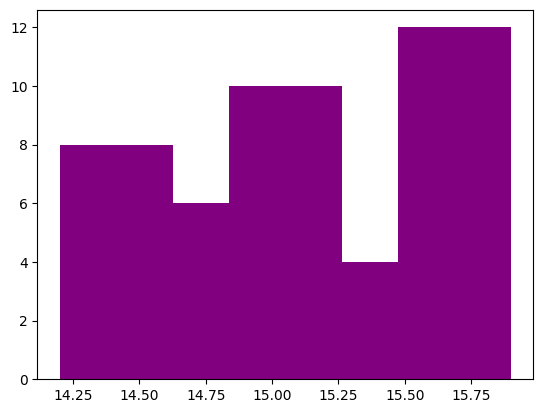

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
n = 50
k = 6  # 初始化小区间划分的个数
a = np.loadtxt("Pdata4_20.txt")
# 专门用于把多维数组“压扁”成一维数组，对结果做任何修改都不会影响原数组
a = a.flatten()
miu = a.mean()
s = a.std()
print(f"均值为：{miu}")
print(f"标准差为：{s}")
print(f"最大值为：{a.max()}")
print(f"最小值为为：{a.min()}")
bins = np.array([14.2, 14.625, 14.8375, 15.05, 15.2625, 15.475, 15.9])
h = plt.hist(a, bins, color='purple')  # 返回两个一维数组，自动均分
f = h[0]  # 取出第一个一维数组————各个小区间频数
x = h[1]  # 取出第二个一维数组————各个小区间端点值
print(f"各区间的频数为：{f}\n小区间端点值为：{x}")
p = ss.norm.cdf(x, miu, s)  # 计算各个分点分布函数的取值,共7个
# diff()“差分”函数，用于沿指定轴计算相邻元素之间的差值，数组后一项减前一项
dp = np.diff(p)  # 计算各小区间取值的理论概率，共6个
dp[0] = ss.norm.cdf(x[1], miu, s)  # 修改第一个区间的概率值，应该为[-oo,14.625],而不是[14.2,14.625]的
dp[-1] = 1 - ss.norm.cdf(x[-2], miu, s)  # 修改最后一个区间的概率值,应该为1-前五个区间的概率，而只有[15.2625,15.475]还有大于15.475的
print(f"各小区间的概率职位：{dp}")
cha = (f-n*dp)**2/(n*dp)
st = cha.sum()  # 计算卡方统计量的值
# 上面两句等价于
# st = sum((f**2/(n*dp))) - n
# k=6,r=2(miu,sigma)
bd = ss.chi2.ppf(0.95, 6-2-1)  # 计算上alpha分位数
print(f"统计量为：{st}，临界值为：{bd}")

##### (2) Kolmogorov-Smirnov 检验(K-S检验)

检验拟合优度最自然的想法就是：测量经验分布函数$F_n(x)$和所拟合的分布函数$F(x)$之间的距离，距离越小，说明拟合效果越好. 这个距离通常由上确界或二次范数来测量，称经验分布函数$F_n(x)$和所拟合的分布函数$F(x)$之间距离的统计量为经验分布函数 (empirical distribution function, EDF) 统计量，记这些 EDF 统计量为$T$.

在计算了这些统计量之后，目的是依据这些统计量判断分布函数$F(x)$是否可以接受，也就是检验它与经验分布的拟合优度. 通常，检验拟合优度的过程如下：零假设为所指定的分布是可接受的，对立假设为拒绝，
$$
H_0: F_n(x) = F(x; \theta),\quad H_1: F_n(x) \neq F(x; \theta),
$$
$\theta$是所拟合分布中的参数 (或参数向量). 统计量$T$取较小的值时，说明经验分布函数$F_n(x)$和所拟合分布函数$F(x)$之间的距离较小，证明零假设是可接受的. 当统计量$T$的值较大时，说明零假设是不能被接受的. 为了看看到底统计量$T$取多大的值时，零假设是可以接受的，来计算$p$值：
$$
p = P\{T \geq t\}, 
$$
这里的$t$是由样本计算出来的检验值，即 EDF 统计量的值. 当得到较小的$p$值时，就拒绝零假设.

定义 4.10 定义 Kolmogorov-Smirnov 检验统计量为
$$
T = \sup_{x} |F_n(x) - F(x)|, 
$$
这是最常用的统计量，因为上确界是测量经验分布函数$F_n(x)$和理论分布函数$F(x)$之间距离的最自然的量.

(续例 4.6) 检验学生的体重是否服从正态分布.

计算得样本均值和样本标准差分别为
$$
\bar{x} = 61.27,\quad s = 6.8584.
$$

提出假设
$$
H_0: F(x) = \frac{1}{\sqrt{2\pi}\hat{\sigma}} e^{-\frac{(x - \hat{\mu})^2}{2\hat{\sigma}^2}},\quad H_1: F(x) \neq \frac{1}{\sqrt{2\pi}\hat{\sigma}} e^{-\frac{(x - \hat{\mu})^2}{2\hat{\sigma}^2}},
$$
其中$\hat{\mu} = \bar{x} = 61.27$, $\hat{\sigma} = s = 6.8584$，利用 Python 软件，计算得 KS 统计量的值为 0.0590, $p$值为 0.8767，所以接受原假设，认为学生的体重服从正态分布.

scipy.stats.kstest(数据向量, 'cdf'('待检验的分布'), (传给cdf的位置参数))

| 参数            | 类型 / 默认值                                          | 说明                                                                                                        |
| ------------- | ------------------------------------------------- | --------------------------------------------------------------------------------------------------------- |
| `rvs`         | array-like, 1-D                                   | 样本数据向量                                                                                                    |
| `cdf`         | str 或 callable                                    | 待检验的理论分布：<br>- 字符串：`'norm'`, `'expon'`, `'t'` … 任意 `scipy.stats` 中的连续分布名<br>- 可调用对象：直接给出 CDF 函数           |
| `args`        | tuple, `()`                                       | 传给 `cdf` 的位置参数（如 `('norm', 0, 1)` 可写成 `cdf='norm', args=(0, 1)`）                                          |
| `N`           | int, `None`                                       | 仅当 `cdf='norm'` 且 `args` 为空时有效；若指定，则使用 Lilliefors 修正（样本估计 μ, σ）                                           |
| `alternative` | `{'two-sided', 'less', 'greater'}`, `'two-sided'` | 备择假设方向：<br>- `'two-sided'`：经验 ≠ 理论<br>- `'less'`：经验 CDF 始终在理论 CDF 下方<br>- `'greater'`：经验 CDF 始终在理论 CDF 上方 |
| `mode`        | `{'auto', 'exact', 'approx', 'asymp'}`, `'auto'`  | 计算 p 值的方法                                                                                                 |
| 返回值         | 说明                  | 类型      |
| ----------- | ------------------- | ------- |
| `statistic` | KS 距离 D（两分布间的最大垂直差） | `float` |
| `pvalue`    | 对应 p 值              | `float` |


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
a = np.loadtxt("Pdata4_6_2.txt")
w = a[:, 1::2]
w = w.flatten()
miu = w.mean()
s = w.std(ddof=1)  # 计算样本的均值和标准差
print(f"均值和标准差分别为：{(miu, s)}")
statVal, pVal = ss.kstest(w, 'norm', (miu, s))
print(f"统计量为：{statVal}")
print(f"p值为：{pVal}")

均值和标准差分别为：(61.27, 6.892911012208283)
统计量为：0.05904454095634937
p值为：0.8561177331775733


注 4.2 NumPy 库中，标准差和方差默认除以 n (n 为样本容量）， statsmodels
库中，标准差和方差默认除以 n-1. 
